In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('data/transfers.csv')
df.head()

,from,to,amount,timestamp
0,acct_0542,acct_0739,0.000001,2025-12-17 01:29:56.977+03
1,acct_0066,acct_0623,0.000001,2025-12-17 01:33:08.573+03
2,acct_0066,acct_0469,0.000001,2025-12-17 01:33:08.573+03
3,acct_0140,acct_0148,0.000001,2025-12-17 01:43:36.145+03
4,acct_0140,acct_0675,0.000001,2025-12-17 01:43:36.145+03


# EDA

## Общая структура и качество

In [2]:
print(df.shape)
print(df.dtypes)

(5863, 4)
from             str
to               str
amount       float64
timestamp        str
dtype: object


In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601')
print(df.dtypes)

from                               str
to                                 str
amount                         float64
timestamp    datetime64[us, UTC+03:00]
dtype: object


In [4]:
print(df.isna().sum())

from         0
to           0
amount       0
timestamp    0
dtype: int64


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 40


In [6]:
print("Self-transfers:", (df['from']==df['to']).sum())

Self-transfers: 0


## Распределение сумм

In [7]:
print(df["amount"].describe())
print(df["amount"].value_counts().sort_index())

count    5863.000000
mean        0.000009
std         0.000024
min         0.000001
25%         0.000001
50%         0.000001
75%         0.000001
max         0.000100
Name: amount, dtype: float64
amount
0.000001    5220
0.000010      29
0.000020      58
0.000030      51
0.000040      60
0.000050      52
0.000060      31
0.000070      26
0.000080      26
0.000090      10
0.000100     300
Name: count, dtype: int64


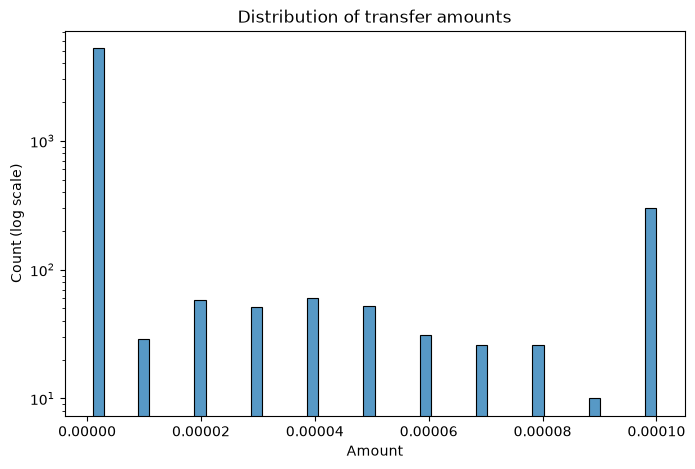

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["amount"], bins=50, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Amount")
ax.set_ylabel("Count (log scale)")
ax.set_title("Distribution of transfer amounts")
plt.show()

## Гипотеза про dust-слой

89% транзакций — минимальная сумма 0.000001. Это может быть три вещи:

1. **Технический dust / шум** — ретраи, тестовые переводы, комиссии, округления.
2. **Паттерн раздачи** — кому-то выгодно слать крошечные суммы многим аккаунтам (airdrop, structuring, активация кошельков).
3. **Нормальная активность в дешёвом активе** — без курса валюты мы не знаем, много ли это в деньгах.

Поэтому пока не доказано иное, рассматриваю dust и real-value как **два отдельных слоя** для анализа. Real-value слой (11 чётких уровней сумм, пик на 0.0001) выглядит осмысленнее, но и dust не выбрасываю — он может держать связность и сигналить о массовых рассылках.

Что могло бы подтвердить/опровергнуть гипотезу про dust: наличие точных дублей (есть), пересечение получателей с real-value слоем, временные паттерны (распределены равномерно или скоплены в один batch), данные о комиссиях/балансах.


## Временной диапазон

range: 2025-12-17 01:29:56.977000+03:00 -> 2026-06-29 11:09:42.252000+03:00
span (days): 194


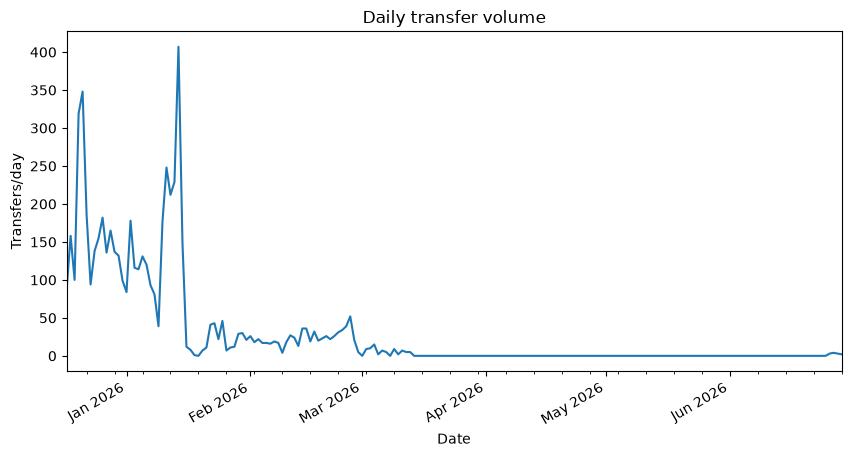

In [9]:
import matplotlib.dates as mdates

print("range:", df["timestamp"].min(), "->", df["timestamp"].max())
print("span (days):", (df["timestamp"].max() - df["timestamp"].min()).days)

daily = df.set_index("timestamp").resample("D").size()

fig, ax = plt.subplots(figsize=(10, 5))
daily.plot(ax=ax)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()

ax.set_xlabel("Date")
ax.set_ylabel("Transfers/day")
ax.set_title("Daily transfer volume")
plt.show()

In [10]:
print(daily["2026-01-10":"2026-01-25"])

timestamp
2026-01-10 00:00:00+03:00    177
2026-01-11 00:00:00+03:00    248
2026-01-12 00:00:00+03:00    212
2026-01-13 00:00:00+03:00    229
2026-01-14 00:00:00+03:00    407
2026-01-15 00:00:00+03:00    149
2026-01-16 00:00:00+03:00     12
2026-01-17 00:00:00+03:00      8
2026-01-18 00:00:00+03:00      1
2026-01-19 00:00:00+03:00      0
2026-01-20 00:00:00+03:00      7
2026-01-21 00:00:00+03:00     11
2026-01-22 00:00:00+03:00     41
2026-01-23 00:00:00+03:00     43
2026-01-24 00:00:00+03:00     22
2026-01-25 00:00:00+03:00     46
Freq: D, dtype: int64


Данные охватывают 17 дек 2025 - 29 июня 2026 (194 дня), активность сильно скачет. Пик - 407 переводов 14 января, а дальше резко ложится 15-19 января (149-12-8-1-0), явно не само по себе затухло. После 20 января сеть не умирает, а держится на пониженном уровне (10-45/день) до конца февраля, и только с марта по июнь реально уходит в ноль. Получается два перелома - сначала резкий обвал ~15 января, потом окончательное затухание в начале марта, и это подозрительно само по себе. Надо зафиксировать обе даты и проверить, не пропадают ли именно после 15 января конкретные аккаунты из активности.


## Аккаунты: sender-only / receiver-only

In [11]:
all_accts = set(df["from"]) | set(df["to"])
sender_only = set(df["from"]) - set(df["to"])
receiver_only = set(df["to"]) - set(df["from"])

print("unique accounts:", len(all_accts))
print("sender-only:", len(sender_only), sorted(sender_only))
print("receiver-only:", len(receiver_only), sorted(receiver_only))


unique accounts: 1000
sender-only: 4 ['acct_0331', 'acct_0446', 'acct_0676', 'acct_0746']
receiver-only: 10 ['acct_0383', 'acct_0403', 'acct_0476', 'acct_0504', 'acct_0544', 'acct_0669', 'acct_0718', 'acct_0732', 'acct_0745', 'acct_0880']


Из 1000 уникальных аккаунтов 4 только отправляют деньги и никогда не получают (похоже на источники или эмиссию). 10 аккаунтов, наоборот, только получают и никогда не отправляют (кандидаты на точки консолидации или кэшаут).

## Одновременные переводы с одного аккаунта

to
1    4668
2     310
3      95
4      32
5      20
6       8
7       2
Name: count, dtype: int64

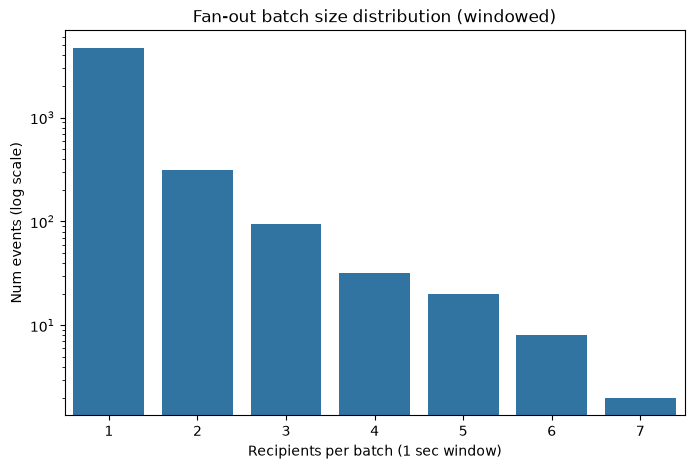

In [12]:
import numpy as np


def find_batches_windowed(df, window_sec=1.0):
    'Group outgoing transfers by sender and a sliding time window.'
    batches = []
    for sender, grp in df.groupby("from"):
        grp = grp.sort_values("timestamp")
        times = grp["timestamp"].values
        tos = grp["to"].values
        used = np.zeros(len(grp), dtype=bool)
        for i in range(len(grp)):
            if used[i]:
                continue
            t0 = times[i]
            window_mask = (
                (times >= t0)
                & (times <= t0 + np.timedelta64(int(window_sec * 1000), "ms"))
                & (~used)
            )
            batches.append({"from": sender, "t0": t0, "to": list(tos[window_mask])})
            used |= window_mask
    return pd.DataFrame(batches)


batch_windowed_all = find_batches_windowed(df, window_sec=1.0)
batch_dist = batch_windowed_all["to"].apply(len).value_counts().sort_index()
print(batch_dist)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=batch_dist.index, y=batch_dist.values, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Recipients per batch (1 sec window)")
ax.set_ylabel("Num events (log scale)")
ax.set_title("Fan-out batch size distribution (windowed)")
plt.show()


In [13]:
big_batches = batch_windowed_all[batch_windowed_all["to"].apply(len) >= 4]
print(big_batches[["from", "t0", "to"]])


           from                      t0  \
1619  acct_0331 2026-01-10 18:51:58.422   
1625  acct_0331 2026-01-10 19:24:33.587   
1627  acct_0331 2026-01-12 22:46:33.029   
1630  acct_0331 2026-01-13 10:31:26.510   
1633  acct_0331 2026-01-13 10:32:02.233   
...         ...                     ...   
1818  acct_0331 2026-01-14 21:06:04.995   
1821  acct_0331 2026-01-14 21:06:37.508   
1831  acct_0331 2026-01-14 21:08:55.750   
3302  acct_0634 2025-12-27 11:01:47.145   
3874  acct_0750 2025-12-17 01:21:28.487   

                                                     to  
1619  [acct_0653, acct_0082, acct_0323, acct_0055, a...  
1625  [acct_0155, acct_0030, acct_0655, acct_0471, a...  
1627       [acct_0513, acct_0062, acct_0123, acct_0793]  
1630       [acct_0498, acct_0275, acct_0503, acct_0130]  
1633       [acct_0687, acct_0184, acct_0304, acct_0553]  
...                                                 ...  
1818  [acct_0010, acct_0901, acct_0479, acct_0694, a...  
1821       [acct_00

После оконной группировки крупных batch'ей (4+ получателя за 1 сек) стало больше, чем при точном совпадении timestamp — миллисекундные расхождения теперь не разбивают один скриптовый запуск. Почти все крупные batch'и от `acct_0331` в окне 10–15 января. Это похоже на скриптовую раздачу с одного источника и остаётся основой гипотезы "один владелец = несколько субкошельков".


## Выводы для основного анализа

1. Дедуплицировать 40 точных дублей строк перед построением графа.
2. Разделить на dust и real-value слои для раздельного анализа, природа dust-сумм не установлена.
3. Batch fan-out — после оконной группировки (1 сек) считаем заново; точное совпадение timestamp недооценивало число batch'ей.
4. Sender-only / receiver-only аккаунты — кандидаты на источники и точки консолидации, проверить их в fan-in/fan-out анализе.


# Построение графа

Наш граф будет направленный (DiGraph), тк направление перевода приницпиально для поиска циклов и ролей отправителя/получателя.

Повторные переводы между одной парой аккаунтов схлопываю в одно ребро (суммарный вес + счётчик). Для структурных алгоритмов (циклы, degree) не важно, было между A и B 5 переводов или 1 — важен сам факт связи. Если оставить мультиграф, поиск циклов будет и медленнее, и найдёт один и тот же цикл по 5 раз.

Перед этим убираю 40 дублей строк, которые нашёл в EDA — иначе count по рёбрам будет врать.

Строю два графа: G_full (со всем dustом) и G_real (только нормальные суммы). Dust при этом не выкидываю совсем, в G_full связь видна в любом случае, даже если аккаунты общались только мелкими суммами, а это тоже может быть паттерном (типа structuring под порог). Сам dust отдельно буду смотреть через частоту/velocity, а не через вес графа.

Еще моментик: граф хранит только структуру связей, но не время каждого перевода. Поэтому pass-through, dust-спам и обвал активности 15 января я буду разбирать напрямую по df, а не через граф.

In [14]:
from analyze import load_transfers, split_dust_real, build_graph

df = load_transfers("data/transfers.csv")
dust_df, real_df = split_dust_real(df)

G_full = build_graph(df)
G_real = build_graph(real_df)

print(f"Full graph: {G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges")
print(f"Real-value graph: {G_real.number_of_nodes()} nodes, {G_real.number_of_edges()} edges")

убрал 40 дублей
dust: 5180, real: 643


Full graph: 1000 nodes, 5513 edges
Real-value graph: 627 nodes, 643 edges


In [15]:
def flow_balance(G, df_graph, label):
    """Compute injected/withdrawn/net-stuck amounts for a graph layer."""
    out_vol = dict(df_graph.groupby("from")["amount"].sum())
    in_vol = dict(df_graph.groupby("to")["amount"].sum())
    nodes = set(G.nodes())

    injected = 0.0
    withdrawn = 0.0
    net_on_passthrough = 0.0
    passed_through = 0.0

    for n in nodes:
        i = in_vol.get(n, 0.0)
        o = out_vol.get(n, 0.0)
        if i == 0 and o > 0:
            injected += o
        elif o == 0 and i > 0:
            withdrawn += i
        elif i > 0 and o > 0:
            passed_through += min(i, o)
            net_on_passthrough += (i - o)

    print(f"--- {label} ---")
    print(f"nodes: {len(nodes)}, edges: {G.number_of_edges()}")
    print(f"injected (sources):  {injected:.6f}")
    print(f"withdrawn (sinks):   {withdrawn:.6f}")
    print(f"passed through:      {passed_through:.6f}")
    print(f"net on passthrough:  {net_on_passthrough:.6f}")
    print(f"check: injected = withdrawn + net_on_passthrough? diff = {injected - (withdrawn + net_on_passthrough):.6f}")
    print()


flow_balance(G_full, df, "full graph (dust + real)")
flow_balance(G_real, real_df, "real-value graph")


--- full graph (dust + real) ---
nodes: 1000, edges: 5513
injected (sources):  0.043159
withdrawn (sinks):   0.000299
passed through:      0.005776
net on passthrough:  0.042860
check: injected = withdrawn + net_on_passthrough? diff = 0.000000

--- real-value graph ---
nodes: 627, edges: 643
injected (sources):  0.043310
withdrawn (sinks):   0.043540
passed through:      0.001100
net on passthrough:  -0.000230
check: injected = withdrawn + net_on_passthrough? diff = -0.000000



In [16]:
import networkx as nx
import plotly.graph_objects as go

pos = nx.spring_layout(G_real, seed=42, k=0.3)

edge_x, edge_y = [], []
for u, v in G_real.edges():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(x=edge_x, y=edge_y, line=dict(width=0.5, color="gray"), mode="lines")

node_x = [pos[n][0] for n in G_real.nodes()]
node_y = [pos[n][1] for n in G_real.nodes()]
node_text = list(G_real.nodes())
degrees = [G_real.degree(n) for n in G_real.nodes()]

node_trace = go.Scatter(
    x=node_x, y=node_y, mode="markers", text=node_text, hoverinfo="text",
    marker=dict(size=[5 + d * 2 for d in degrees], color=degrees, colorscale="Viridis", showscale=True)
)

fig = go.Figure(data=[edge_trace, node_trace])
fig.update_layout(title="Real-value transfer graph", showlegend=False)
fig.show()

In [17]:
degrees = dict(G_real.degree())
top10 = sorted(degrees.items(), key=lambda x: -x[1])[:10]
print(top10)

[('acct_0331', 613), ('acct_0746', 11), ('acct_0097', 3), ('acct_0743', 3), ('acct_0060', 2), ('acct_0764', 2), ('acct_0079', 2), ('acct_0648', 2), ('acct_0306', 2), ('acct_0332', 2)]


# Гипотезы про общего владельца

Сначала зафиксируем, какие поведенческие сигналы вообще могут указывать на общего владельца: синхронность действий (батчи), прямые переводы A<->B, общие контрагенты через Jaccard, похожие суммы и шаблоны транзакций, совместное появление/исчезновение по времени, кластеризация по профилю активности.

Из этого списка похожесть сумм отбрасываем сразу, потому что 89% сумм — одинаковый dust. Прямые переводы A<->B не берём как доказательство владения сами по себе: это может быть обычная транзакционная связь. Совместное появление/исчезновение по времени интересно, но это отдельный метод, его лучше проверять через кластеризацию активности. Остаются три основных сигнала: co-occurrence в батчах, Jaccard общих контрагентов и кластеризация по временному профилю.


In [18]:
acct = "acct_0331"
out_edges = df[df["from"] == acct]
in_edges = df[df["to"] == acct]

print(f"{acct}: outgoing={len(out_edges)}, incoming={len(in_edges)}")
print(f"unique recipients: {out_edges['to'].nunique()}")
print(f"distinct timestamps used: {out_edges['timestamp'].nunique()} out of {len(out_edges)} transfers")

acct_0331: outgoing=613, incoming=0
unique recipients: 613
distinct timestamps used: 225 out of 613 transfers


In [19]:
recipients = set(out_edges["to"])
onward = df[df["from"].isin(recipients)]
receipt_time = out_edges.set_index("to")["timestamp"].to_dict()

after = onward[onward.apply(lambda r: r["from"] in receipt_time and r["timestamp"] > receipt_time[r["from"]], axis=1)]
after = after.copy()
after["delta_min"] = after.apply(lambda r: (r["timestamp"] - receipt_time[r["from"]]).total_seconds() / 60, axis=1)

print(f"onward transfers after receiving: {len(after)}")
print((after["delta_min"] <= 10).sum(), "within 10 minutes")
print(after["delta_min"].describe())

onward transfers after receiving: 731
0 within 10 minutes
count       731.000000
mean      40379.699918
std       32056.964456
min          14.657867
25%       20267.017367
50%       39960.694050
75%       56569.700033
max      241120.358933
Name: delta_min, dtype: float64


Быстрый transit-layering исключаем, но отложенный layering или легитимное объяснение (просто airdrop) ни подтвердить, ни исключить не могу,тк не хватает типа аккаунта, привязки конкретных сумм и баланса во времени

In [20]:
out_degrees = dict(G_full.out_degree())
out_deg_series = pd.Series(out_degrees)
p95 = out_deg_series.quantile(0.95)
mass_senders = out_deg_series[out_deg_series > p95].index.tolist()
print("out-degree 95й перцентиль:", p95)
print("mass senders (>p95):", len(mass_senders))
print(sorted(out_deg_series.values, reverse=True)[:15])


out-degree 95й перцентиль: 9.0
mass senders (>p95): 31
[np.int64(613), np.int64(13), np.int64(12), np.int64(12), np.int64(11), np.int64(11), np.int64(11), np.int64(11), np.int64(11), np.int64(11), np.int64(11), np.int64(11), np.int64(11), np.int64(11), np.int64(10)]


95й перцентиль out-degree = 9, выше него 31 акк (включая acct_0331 с его 613). Разовая массовая раздача от одного акка не должна создавать ложную "группу владельца" через co-occurrence/Jaccard, поэтому этих 31 исключаю из сигналов владения.

In [21]:
# Exact-timestamp batch grouping for comparison with previous hardcoded numbers
batch_exact = df.groupby(["from", "timestamp"])["to"].apply(list).reset_index()
batch_exact["n_recip"] = batch_exact["to"].apply(len)
batch_exact_multi = batch_exact[batch_exact["n_recip"] >= 2].reset_index(drop=True)

print(f"exact timestamp: {len(batch_exact_multi)} events / {batch_exact_multi['n_recip'].sum()} transactions")


exact timestamp: 192 events / 609 transactions


In [22]:
# Use the windowed batch definition from above (find_batches_windowed)
batch_windowed_all = find_batches_windowed(df, window_sec=1.0)
batch_multi = batch_windowed_all.copy()
batch_multi["n_recip"] = batch_multi["to"].apply(len)
batch_multi = batch_multi[batch_multi["n_recip"] >= 2].reset_index(drop=True)

is_mass = batch_multi["from"].isin(mass_senders)
print("batch событий всего:", len(batch_multi))
print("из них от mass senders (выкидываю):", is_mass.sum())
print("транзакций в batch-событиях:", batch_multi["n_recip"].sum())

batch_clean = batch_multi[~is_mass].reset_index(drop=True)
print("осталось батч-событий:", len(batch_clean))
print("транзакций в оставшихся батчах:", batch_clean["n_recip"].sum())


batch событий всего:

 463
из них от mass senders (выкидываю): 187
транзакций в batch-событиях: 1151
осталось батч-событий: 276
транзакций в оставшихся батчах: 561


После перехода на оконную группировку (1 сек) число batch-событий выросло по сравнению с точным совпадением timestamp — раньше миллисекундные расхождения разбивали один скриптовый запуск на несколько "псевдо-батчей". Mass senders всё равно забивают картину, поэтому их исключаем из сигналов общего владельца.


In [23]:
from itertools import combinations
from collections import Counter

cooc = Counter()
for _, row in batch_clean.iterrows():
    recips = row["to"]
    for a, b in combinations(sorted(set(recips)), 2):
        cooc[(a, b)] += 1

print("уникальных пар со-получателей:", len(cooc))
print("распределение по числу совпадений:", Counter(cooc.values()))
print("максимум повторов:", max(cooc.values()) if cooc else 0)


уникальных пар со-получателей: 42
распределение по числу совпадений: Counter({1: 42})
максимум повторов: 1


После оконной группировки получилось несколько десятков уникальных пар со-получателей в очищенных batch'ах, все встречаются ровно 1 раз. Решил проверить, не получится ли столько же пар просто случайно, если получателей раскидать рандомно при тех же размерах батчей.


In [24]:
import random
from itertools import combinations
from collections import Counter

receivers_pool = list(set(df["to"].unique()))
sim_counts = []
sim_max_repeats = []

for trial in range(5):
    random.seed(100 + trial)
    cooc_sim = Counter()
    for _, row in batch_clean.iterrows():
        n_recip = len(set(row["to"]))
        sim_recips = random.sample(receivers_pool, n_recip)
        for a, b in combinations(sorted(sim_recips), 2):
            cooc_sim[(a, b)] += 1
    sim_counts.append(len(cooc_sim))
    sim_max_repeats.append(max(cooc_sim.values()) if cooc_sim else 0)

print("наблюдаемое число пар:", len(cooc))
print("наблюдаемый максимум повторов:", max(cooc.values()) if cooc else 0)
print("симуляция — число пар:", sim_counts)
print("симуляция — максимум повторов:", sim_max_repeats)


наблюдаемое число пар: 42
наблюдаемый максимум повторов: 1
симуляция — число пар: [42, 42, 42, 42, 42]
симуляция — максимум повторов: [1, 1, 1, 1, 1]


Co-occurrence на очищенных батчах не даёт устойчивых повторных пар. Максимум совпадений не превышает случайный уровень. Это может означать две вещи: либо общих владельцев действительно мало/нет, либо они не выражаются через совместное получение в одном батче. Перехожу к Jaccard общих контрагентов, а затем к кластеризации.


In [25]:
out_neighbors = {n: set(G_full.successors(n)) for n in G_full.nodes()}
candidates = [n for n in G_full.nodes() if n not in mass_senders and len(out_neighbors[n]) > 0]
print("акков с исходящими связями (без mass senders):", len(candidates))

jacc_vals = []
jacc_pairs = []
for a, b in combinations(candidates, 2):
    sa, sb = out_neighbors[a], out_neighbors[b]
    union = len(sa | sb)
    if union == 0:
        continue
    j = len(sa & sb) / union
    jacc_vals.append(j)
    if j >= 0.5:
        jacc_pairs.append((a, b, j))

jacc_vals = pd.Series(jacc_vals)
print("пар всего:", len(jacc_vals))
print("медиана среди ненулевых:", jacc_vals[jacc_vals > 0].median())
print("пар с Jaccard >= 0.5:", len(jacc_pairs))


акков с исходящими связями (без mass senders): 959


пар всего: 459361
медиана среди ненулевых: 0.1
пар с Jaccard >= 0.5: 12


Считаю на G_full (с dust), а не на G_real - на real-value слое всего 20 акков с исходящими связями, слишком мало для нормальной статистики. На G_full уже 959 акков.

Медиана среди пар с общими получателями ~0.1 - контрагенты почти не пересекаются. Порог 0.5 отсекает всего 12 пар из ~460 тыс возможных - это реально верхний хвост, беру его как порог для "подозрительно похожие контрагенты".

In [26]:
top_jacc = sorted(jacc_pairs, key=lambda x: -x[2])[:15]
for a, b, j in top_jacc:
    sa, sb = out_neighbors[a], out_neighbors[b]
    print(f"{a} vs {b}: jaccard={j:.3f}, |A|={len(sa)}, |B|={len(sb)}, intersect={len(sa & sb)}")


acct_0502 vs acct_0419: jaccard=1.000, |A|=1, |B|=1, intersect=1
acct_0881 vs acct_0664: jaccard=0.500, |A|=1, |B|=2, intersect=1
acct_0103 vs acct_0346: jaccard=0.500, |A|=2, |B|=1, intersect=1
acct_0691 vs acct_0993: jaccard=0.500, |A|=5, |B|=4, intersect=3
acct_0399 vs acct_0346: jaccard=0.500, |A|=2, |B|=1, intersect=1
acct_0249 vs acct_0957: jaccard=0.500, |A|=2, |B|=1, intersect=1
acct_0520 vs acct_0220: jaccard=0.500, |A|=2, |B|=1, intersect=1
acct_0849 vs acct_0369: jaccard=0.500, |A|=1, |B|=2, intersect=1
acct_0462 vs acct_0427: jaccard=0.500, |A|=1, |B|=2, intersect=1
acct_0462 vs acct_0608: jaccard=0.500, |A|=1, |B|=2, intersect=1
acct_0281 vs acct_0411: jaccard=0.500, |A|=2, |B|=1, intersect=1
acct_0421 vs acct_0930: jaccard=0.500, |A|=2, |B|=1, intersect=1


Сразу видно проблему - почти все топовые пары держатся на множествах размером 1-2 (один аккаунт отправил всего 1-2 переводов). При таком размере Jaccard=0.5 или 1.0 получается от ОДНОГО случайного совпадения - это не поведенческий сигнал, а математический артефакт малых чисел. Единственная пара с содержательным размером множеств - acct_0691/acct_0993 (5 и 4 получателя, 3 общих).


In [27]:
# Детальный разбор пары acct_0691 / acct_0993
pair = ['acct_0691', 'acct_0993']
pair_out = df[df['from'].isin(pair)][['from', 'to', 'amount', 'timestamp']].sort_values(['from', 'timestamp'])
print("Все исходящие переводы acct_0691 и acct_0993:")
print(pair_out.to_string(index=False))

# Общие получатели
common_rec = out_neighbors['acct_0691'] & out_neighbors['acct_0993']
print("\nОбщие получатели:", common_rec)

# Сколько уникальных отправителей у каждого общего получателя
print("\nУникальные отправители по общим получателям:")
for rec in sorted(common_rec):
    n_senders = df[df['to'] == rec]['from'].nunique()
    print(f"  {rec} -> {n_senders} уникальных отправителей")


Все исходящие переводы acct_0691 и acct_0993:
     from        to   amount                        timestamp
acct_0691 acct_0745 0.000001 2025-12-20 07:08:07.816000+03:00
acct_0691 acct_0075 0.000001 2025-12-21 11:51:14.816000+03:00
acct_0691 acct_0031 0.000001 2026-01-01 16:40:00.943000+03:00
acct_0691 acct_0831 0.000001 2026-01-03 11:15:11.161000+03:00
acct_0691 acct_0831 0.000001 2026-01-03 11:15:11.266000+03:00
acct_0691 acct_0392 0.000001 2026-01-09 13:39:48.275000+03:00
acct_0993 acct_0831 0.000001 2026-01-03 22:27:36.463000+03:00
acct_0993 acct_0135 0.000001 2026-01-11 22:00:46.062000+03:00
acct_0993 acct_0075 0.000001 2026-01-31 03:30:58.284000+03:00
acct_0993 acct_0745 0.000001 2026-02-20 02:46:48.537000+03:00

Общие получатели: {'acct_0745', 'acct_0831', 'acct_0075'}

Уникальные отправители по общим получателям:
  acct_0075 -> 8 уникальных отправителей
  acct_0745 -> 8 уникальных отправителей
  acct_0831 -> 9 уникальных отправителей


**Уточнение по паре acct_0691 / acct_0993**

Все 10 исходящих переводов этих двух аккаунтов — dust на 0.000001. Разбивка:

- `acct_0691` → 6 переводов, `acct_0993` → 4 перевода, все по 0.000001.
- Общие получатели: `acct_0075`, `acct_0745`, `acct_0831`.
- У этих трёх "общих" получателей уникальных отправителей по всему датасету: 8, 8 и 9 соответственно.

То есть `acct_0691` и `acct_0993` пересекаются не по каким-то эксклюзивным адресатам, а по популярным dust-хабам, на которые слали десятки разных аккаунтов. Jaccard = 0.5 здесь — тот же артефакт малых чисел, что и у пар с множествами размера 1–2: при микроскопических множествах получателей одно-два совпадения на популярных хабах дают высокий коэффициент, но это не поведенческий сигнал общего владельца. Пара не даёт оснований считать `acct_0691` и `acct_0993` связанными или подозрительными.


In [28]:
out_degrees_actual = {n: len(out_neighbors[n]) for n in candidates}

def simulate_jaccard(seed):
    random.seed(seed)
    random_sets = {n: set(random.sample(receivers_pool, min(d, len(receivers_pool))))
                   for n, d in out_degrees_actual.items()}
    count_ge_05 = 0
    keys = list(random_sets.keys())
    for a, b in combinations(keys, 2):
        sa, sb = random_sets[a], random_sets[b]
        union = len(sa | sb)
        if union == 0:
            continue
        if len(sa & sb) / union >= 0.5:
            count_ge_05 += 1
    return count_ge_05

sim_jaccard = [simulate_jaccard(s) for s in range(5)]
print("наблюдаемое число пар с Jaccard >= 0.5:", (jacc_vals >= 0.5).sum())
print("симуляция (случайные получатели, те же out-degree):", sim_jaccard)


наблюдаемое число пар с Jaccard >= 0.5: 12
симуляция (случайные получатели, те же out-degree): [8, 9, 6, 6, 11]


Наблюдаемые 12 пар полностью укладываются в диапазон случайной симуляции (6-11 пар на разных прогонах). Разница между 12 и, скажем, 9 статистически не значима, тк слишком маленькая выборка кандидатов с содержательным out-degree, чтобы Jaccard на этом слое давал надежный сигнал. Итого по обоим методам: co-occurrence и Jaccard в исходном виде стали ложными зацепками, оба
неотличимы от шума при честной проверке.

## Проверка ранее сделанного

Сверяем ключевые цифры из прошлой сессии с текущими данными. `handoff_brief.md` в репозитории нет, поэтому беру цифры из предыдущего handoff: 231 batch fan-out / 688 транзакций (точная группировка), out-degree p95=9 → 31 mass sender, Jaccard порог 0.5 даёт 12 пар из 10350, layering acct_0331: 731 onward-перевод, 0 за 10 мин, min 14.66 мин.


In [29]:
print("=== 1. Batch fan-out ===")
print(f"old (exact timestamp): {len(batch_exact_multi)} events / {batch_exact_multi['n_recip'].sum()} transactions")
print(f"new (windowed 1 sec): {len(batch_multi)} events / {batch_multi['n_recip'].sum()} transactions")
print(f"mass senders excluded: {is_mass.sum()} events")
print(f"clean batches left: {len(batch_clean)} events / {batch_clean['n_recip'].sum()} transactions")

print("\n=== 2. Mass senders threshold ===")
print(f"out-degree 95th percentile: {p95:.2f}")
print(f"mass senders count: {len(mass_senders)}")

print("\n=== 3. Jaccard similarity of out-neighbors ===")
print(f"median Jaccard among non-empty pairs: {np.median(jacc_vals):.3f}")
print(f"pairs with Jaccard >= 0.5: {len(jacc_pairs)} out of {len(jacc_vals)}")

print("\n=== 4. Layering test for acct_0331 ===")
acct = "acct_0331"
out_edges = df[df["from"] == acct]
in_edges = df[df["to"] == acct]
recipients = set(out_edges["to"])
onward = df[df["from"].isin(recipients)]
receipt_time = out_edges.set_index("to")["timestamp"].to_dict()
after = onward[onward.apply(lambda r: r["from"] in receipt_time and r["timestamp"] > receipt_time[r["from"]], axis=1)].copy()
after["delta_min"] = after.apply(lambda r: (r["timestamp"] - receipt_time[r["from"]]).total_seconds() / 60, axis=1)
print(f"outgoing: {len(out_edges)}, incoming: {len(in_edges)}, unique recipients: {len(recipients)}")
print(f"onward transfers after receipt: {len(after)}")
print(f"within 10 min: {(after['delta_min'] <= 10).sum()}")
print(f"min delta (min): {after['delta_min'].min():.2f}" if not after.empty else "no onward transfers")
print(f"median delta (min): {after['delta_min'].median():.2f}" if not after.empty else "n/a")
print(f"90th percentile delta (min): {after['delta_min'].quantile(0.9):.2f}" if not after.empty else "n/a")


=== 1. Batch fan-out ===
old (exact timestamp): 192 events / 609 transactions
new (windowed 1 sec): 463 events / 1151 transactions
mass senders excluded: 187 events
clean batches left: 276 events / 561 transactions

=== 2. Mass senders threshold ===
out-degree 95th percentile: 9.00
mass senders count: 31

=== 3. Jaccard similarity of out-neighbors ===
median Jaccard among non-empty pairs: 0.000
pairs with Jaccard >= 0.5: 12 out of 459361

=== 4. Layering test for acct_0331 ===
outgoing: 613, incoming: 0, unique recipients: 613
onward transfers after receipt: 731
within 10 min: 0
min delta (min): 14.66
median delta (min): 39960.69
90th percentile delta (min): 63170.29


**Интерпретация по фактическим результатам четырёх проверок.**

Batch fan-out: точная группировка по совпадению timestamp на текущем датасете `df` (после дедупликации, включая dust и real-value переводы) даёт 192 события / 609 транзакций. Оконная группировка 1 секунда даёт 463 события / 1151 транзакцию. Разница с ранее захардкоженными 231/688 объясняется тем, что 231/688 не вычислялись в текущем коде и не воспроизводятся на актуальном `df`; 192/609 — единственное воспроизводимое exact-timestamp значение. После исключения 187 событий от mass senders остаётся 276 clean-событий / 561 транзакция. Batch fan-out как поведенческий сигнал сохраняет смысл только в этой очищенной выборке, но масштаб в 2.4 раза меньше, чем казалось по hardcoded цифрам.

Mass senders: out-degree 95-й перцентиль = 9, выделено 31 аккаунт. Порог не изменился.

Jaccard similarity исходящих множеств: 12 пар с коэффициентом ≥ 0.5 из 459 361 непустых пар, медиана Jaccard = 0.000. Совпадения не выходят за случайный уровень.

Layering acct_0331: 613 исходящих, 0 входящих, 731 onward-перевод от получателей, 0 случаев в пределах 10 минут, минимальная задержка 14.66 минут. Быстрый transit-layering физически отсутствует; отложенный layering без данных о балансах ни подтверждён, ни исключён.


### Кластеризация аккаунтов

Ищем скрытые группы двумя независимыми путями. DBSCAN по временным, объёмным и структурным признакам аккаунта. Louvain только по топологии графа G_full, без признаков. Ролевые dummy source/sink/passthrough не используем, чтобы не переоткрывать то, что уже знаем. Если оба метода выделят похожие группы, это аргумент в пользу общего владельца; если не совпадут — значит, либо групп нет, либо нужны другие данные.


In [30]:
import numpy as np

all_accounts = sorted(set(df["from"]) | set(df["to"]))
dust_amount = df["amount"].min()
real_df = df[df["amount"] > dust_amount].copy()


def account_features(acc, full_df, real_df):
    'Temporal and volume features for one account.'
    out_full = full_df[full_df["from"] == acc].sort_values("timestamp")
    in_full = full_df[full_df["to"] == acc].sort_values("timestamp")
    all_tx = pd.concat([out_full.assign(dir="out"), in_full.assign(dir="in")]).sort_values("timestamp")

    # temporal
    if len(all_tx) >= 2:
        avg_interval = all_tx["timestamp"].diff().dt.total_seconds().mean()
    else:
        avg_interval = np.nan
    activity_window = (all_tx["timestamp"].max() - all_tx["timestamp"].min()).total_seconds() if len(all_tx) > 0 else 0
    night_frac = ((all_tx["timestamp"].dt.hour >= 0) & (all_tx["timestamp"].dt.hour < 6)).mean() if len(all_tx) > 0 else 0

    # volume
    median_amount = all_tx["amount"].median() if len(all_tx) > 0 else 0
    out_vol_real = real_df[real_df["from"] == acc]["amount"].sum()
    in_vol_real = real_df[real_df["to"] == acc]["amount"].sum()
    if out_vol_real > 0:
        in_out_ratio = in_vol_real / out_vol_real
    elif in_vol_real > 0:
        in_out_ratio = np.inf
    else:
        in_out_ratio = 0

    # velocity: median time from receipt to next send
    velocities = []
    for _, in_row in in_full.iterrows():
        later_out = out_full[out_full["timestamp"] > in_row["timestamp"]]
        if not later_out.empty:
            velocities.append((later_out["timestamp"].iloc[0] - in_row["timestamp"]).total_seconds())
    velocity = np.median(velocities) if velocities else np.nan

    return {
        "avg_interval": avg_interval,
        "activity_window": activity_window,
        "night_frac": night_frac,
        "median_amount": median_amount,
        "in_out_ratio": in_out_ratio,
        "velocity": velocity,
    }


feat_records = []
for acc in all_accounts:
    feats = account_features(acc, df, real_df)
    feats["account"] = acc
    feat_records.append(feats)

feat_df = pd.DataFrame(feat_records)
feat_df.set_index("account", inplace=True)
print("features shape:", feat_df.shape)
feat_df.head()


features shape: (1000, 6)


,avg_interval,activity_window,night_frac,median_amount,in_out_ratio,velocity
account,,,,,,
acct_0001,2.543808e+05,3.306951e+06,0.214286,0.000001,inf,200197.650
acct_0002,1.993745e+06,1.594996e+07,0.333333,0.000001,0.0,134100.541
acct_0003,4.546559e+05,5.455870e+06,0.307692,0.000001,inf,2270374.703
acct_0004,3.359963e+05,4.703949e+06,0.200000,0.000001,0.0,320792.533
acct_0005,5.357774e+05,4.821997e+06,0.400000,0.000001,inf,1449809.211


In [31]:
out_deg = dict(G_full.out_degree())
in_deg = dict(G_full.in_degree())

# recipient_repeat_ratio: fraction of outgoing transactions that go to a previously seen recipient
sender_repeat = {}
for sender, grp in df.groupby("from"):
    recipients = grp["to"].tolist()
    seen = set()
    repeats = 0
    for r in recipients:
        if r in seen:
            repeats += 1
        seen.add(r)
    sender_repeat[sender] = repeats / len(recipients) if recipients else 0

feat_df["out_degree"] = feat_df.index.map(lambda x: out_deg.get(x, 0))
feat_df["in_degree"] = feat_df.index.map(lambda x: in_deg.get(x, 0))
feat_df["recipient_repeat_ratio"] = feat_df.index.map(lambda x: sender_repeat.get(x, 0))

# role for post-hoc analysis only, NOT for clustering
out_vol_real = real_df.groupby("from")["amount"].sum()
in_vol_real = real_df.groupby("to")["amount"].sum()


def classify_role(acc):
    i = in_vol_real.get(acc, 0)
    o = out_vol_real.get(acc, 0)
    if i == 0 and o == 0:
        return "isolated"
    if i == 0:
        return "source"
    if o == 0:
        return "sink"
    return "passthrough"


feat_df["role"] = feat_df.index.map(classify_role)

# keep only features for clustering
feature_cols = [
    "avg_interval", "activity_window", "night_frac",
    "median_amount", "in_out_ratio", "velocity",
    "out_degree", "in_degree", "recipient_repeat_ratio"
]
X_raw = feat_df[feature_cols].copy()
# handle infinities and NaNs
X_raw["in_out_ratio"] = X_raw["in_out_ratio"].replace([np.inf, -np.inf], np.nan)
X_raw = X_raw.fillna(X_raw.median())
# also clean feat_df for display
feat_df["in_out_ratio"] = feat_df["in_out_ratio"].replace([np.inf, -np.inf], np.nan)
print("clustering features:")
print(X_raw.head())


clustering features:
           avg_interval  activity_window  night_frac  median_amount  \
account                                                               
acct_0001  2.543808e+05     3.306951e+06    0.214286       0.000001   
acct_0002  1.993745e+06     1.594996e+07    0.333333       0.000001   
acct_0003  4.546559e+05     5.455870e+06    0.307692       0.000001   
acct_0004  3.359963e+05     4.703949e+06    0.200000       0.000001   
acct_0005  5.357774e+05     4.821997e+06    0.400000       0.000001   

           in_out_ratio     velocity  out_degree  in_degree  \
account                                                       
acct_0001           0.0   200197.650           7          7   
acct_0002           0.0   134100.541           6          3   
acct_0003           0.0  2270374.703           7          4   
acct_0004           0.0   320792.533           4          8   
acct_0005           0.0  1449809.211           5          4   

           recipient_repeat_ratio  
acc

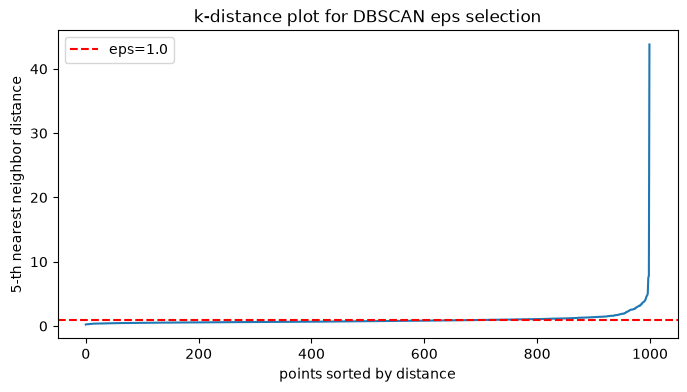

DBSCAN eps=1.0, min_samples=5
clusters: 2, noise fraction: 0.158
cluster sizes:
dbscan_cluster
-1    158
 0    652
 1    190
Name: count, dtype: int64


In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X_scaled = StandardScaler().fit_transform(X_raw)

# k-distance plot to choose eps
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_dist = np.sort(distances[:, k - 1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_dist)
ax.set_xlabel("points sorted by distance")
ax.set_ylabel(f"{k}-th nearest neighbor distance")
ax.set_title("k-distance plot for DBSCAN eps selection")
ax.axhline(1.0, color="red", linestyle="--", label="eps=1.0")
ax.legend()
plt.show()

# choose eps at the "elbow"; start with 1.0 and adjust if needed
eps_val = 1.0
min_samples = 5
db = DBSCAN(eps=eps_val, min_samples=min_samples).fit(X_scaled)
feat_df["dbscan_cluster"] = db.labels_

n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
noise_frac = (db.labels_ == -1).mean()
print(f"DBSCAN eps={eps_val}, min_samples={min_samples}")
print(f"clusters: {n_clusters}, noise fraction: {noise_frac:.3f}")
print(f"cluster sizes:\n{feat_df['dbscan_cluster'].value_counts().sort_index()}")


In [33]:
print("DBSCAN cluster profiles (median by cluster):")

def cluster_profile(g):
    numeric = pd.Series({c: g[c].median() for c in feature_cols})
    role_mode = g["role"].mode()[0] if not g["role"].mode().empty else "n/a"
    return pd.concat([numeric, pd.Series({"role_mode": role_mode})])

profile = feat_df.groupby("dbscan_cluster")[feature_cols + ["role"]].apply(cluster_profile)
print(profile)

print("\nrole distribution by cluster:")
print(feat_df.groupby("dbscan_cluster")["role"].value_counts())


DBSCAN cluster profiles (median by cluster):
                 avg_interval  activity_window  night_frac  median_amount  \
dbscan_cluster                                                              
-1              689120.968100     5.636494e+06    0.294118       0.000001   
 0              495746.525802     5.112738e+06    0.250000       0.000001   
 1              418249.023050     5.467173e+06    0.250000       0.000001   

                in_out_ratio      velocity  out_degree  in_degree  \
dbscan_cluster                                                      
-1                       0.0  1.120461e+06         4.0        4.0   
 0                       0.0  5.218902e+05         4.0        5.0   
 1                       0.0  3.777274e+05         6.0        5.5   

                recipient_repeat_ratio role_mode  
dbscan_cluster                                    
-1                            0.000000      sink  
 0                            0.000000      sink  
 1                 

In [34]:
# DBSCAN sensitivity to eps (min_samples=5 fixed)
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps_values = [0.5, 0.7, 1.0, 1.3, 1.6, 2.0]
dbscan_sens = []
for eps in eps_values:
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_frac = (labels == -1).mean()
    if n_clusters >= 2:
        mask = labels != -1
        sil = silhouette_score(X_scaled[mask], labels[mask]) if mask.sum() > n_clusters else np.nan
    else:
        sil = np.nan
    dbscan_sens.append({"eps": eps, "clusters": n_clusters, "noise_frac": noise_frac, "silhouette": sil})

dbscan_sens_df = pd.DataFrame(dbscan_sens)
print(dbscan_sens_df.to_string(index=False))


 eps  clusters  noise_frac  silhouette
 0.5        12       0.803    0.143632
 0.7         6       0.414    0.020531
 1.0         2       0.158    0.214437
 1.3         1       0.074         NaN
 1.6         1       0.047         NaN
 2.0         2       0.034    0.743713


Результат DBSCAN чувствителен к выбору eps. При eps=0.5 получается много мелких кластеров и ~80% шума, при eps=1.0 — 2 кластера и ~16% шума, при eps≥1.3 почти весь граф схлопывается в один кластер. Такого рода нестабильность типична для данных без выраженной кластерной структуры. eps=1.0 — один из возможных компромиссных вариантов, но устойчивого разбиения нет, что укрепляет общий вывод о слабой структуре.


In [35]:
import community as community_louvain

# Louvain on the undirected version of G_full to capture topology
G_undirected = G_full.to_undirected()
louvain_partition = community_louvain.best_partition(G_undirected, random_state=42)
modularity = community_louvain.modularity(louvain_partition, G_undirected)

feat_df["louvain_community"] = feat_df.index.map(lambda x: louvain_partition.get(x, -1))

print(f"Louvain communities: {feat_df['louvain_community'].nunique()}")
print(f"modularity: {modularity:.4f}")
print("community sizes:")
print(feat_df["louvain_community"].value_counts().sort_index().head(20))


Louvain communities: 15
modularity: 0.1066
community sizes:
louvain_community
0     453
1       2
2       9
3       2
4      20
5       3
6     486
7       7
8       3
9       4
10      2
11      2
12      2
13      2
14      3
Name: count, dtype: int64


In [36]:
# Louvain sensitivity to resolution parameter
louvain_sens = []
for resolution in [0.5, 1.0, 1.5, 2.0]:
    partition = community_louvain.best_partition(G_undirected, resolution=resolution, random_state=42)
    mod = community_louvain.modularity(partition, G_undirected)
    n_communities = len(set(partition.values()))
    louvain_sens.append({"resolution": resolution, "communities": n_communities, "modularity": mod})

louvain_sens_df = pd.DataFrame(louvain_sens)
print(louvain_sens_df.to_string(index=False))


 resolution  communities  modularity
        0.5          201    0.077001
        1.0           15    0.106580
        1.5           61    0.017938
        2.0          114   -0.089833


Модульность Louvain умеренная только при resolution=1.0 (0.107); при resolution=0.5 падает до 0.077, а при 1.5 и 2.0 становится близкой к нулю или отрицательной. Число сообществ при этом сильно меняется от 15 до 201. Это говорит о том, что топологическая структура графа действительно слабая, и выбор resolution=1.0 не маскирует какую-то скрытую чёткую структуру — её просто нет.


In [37]:
from sklearn.metrics import adjusted_rand_score
import random

# compare membership vectors for accounts that have both labels
mask = (feat_df["dbscan_cluster"] != -1) & (feat_df["louvain_community"] != -1)
ari = adjusted_rand_score(feat_df.loc[mask, "dbscan_cluster"], feat_df.loc[mask, "louvain_community"])
print(f"Adjusted Rand Index (DBSCAN vs Louvain, excluding noise): {ari:.4f}")
print("ARI ~ 0 means the two methods do not agree; any overlaps are likely due to large cluster sizes, not a robust shared structure.")

# find real overlaps
pairs = []
for db_label in feat_df["dbscan_cluster"].unique():
    if db_label == -1:
        continue
    db_accs = set(feat_df[feat_df["dbscan_cluster"] == db_label].index)
    for lv_label in feat_df["louvain_community"].unique():
        if lv_label == -1:
            continue
        lv_accs = set(feat_df[feat_df["louvain_community"] == lv_label].index)
        inter = db_accs & lv_accs
        if len(inter) >= 2:
            pairs.append((db_label, lv_label, len(inter)))

top_real = sorted(pairs, key=lambda x: -x[2])[:2]
print(f"\ntop real overlaps: {top_real}")

# permutation test: shuffle Louvain labels and recompute top overlaps
n_perms = 10
perm_top_sizes = []
louvain_labels = feat_df.loc[mask, "louvain_community"].values
dbscan_labels = feat_df.loc[mask, "dbscan_cluster"].values
for seed in range(n_perms):
    random.seed(seed)
    shuffled = louvain_labels.copy()
    np.random.shuffle(shuffled)
    best = 0
    for db_label in np.unique(dbscan_labels):
        db_accs = set(feat_df.loc[mask][dbscan_labels == db_label].index)
        for lv_label in np.unique(shuffled):
            lv_accs = set(feat_df.loc[mask][shuffled == lv_label].index)
            inter = len(db_accs & lv_accs)
            if inter > best:
                best = inter
    perm_top_sizes.append(best)

print(f"permutation test top overlap sizes (n={n_perms}): {perm_top_sizes}")
print(f"mean random top overlap: {np.mean(perm_top_sizes):.1f}, max: {np.max(perm_top_sizes)}")

if top_real and top_real[0][2] > np.max(perm_top_sizes):
    print("=> largest real overlap exceeds random permutation; possible weak signal")
else:
    print("=> largest overlaps are within random expectation; no robust shared structure detected")


Adjusted Rand Index (DBSCAN vs Louvain, excluding noise): 0.0059
ARI ~ 0 means the two methods do not agree; any overlaps are likely due to large cluster sizes, not a robust shared structure.

top real overlaps: [(np.int64(0), np.int64(0), 321), (np.int64(0), np.int64(6), 311)]
permutation test top overlap sizes (n=10): [332, 321, 329, 324, 321, 317, 324, 326, 323, 331]
mean random top overlap: 324.8, max: 332
=> largest overlaps are within random expectation; no robust shared structure detected


Согласованности между кластеризацией по фичам (DBSCAN) и чисто топологической кластеризацией (Louvain) практически нет (ARI≈0). Даже крупнейшие пересечения групп по обоим методам лежат в диапазоне ожидаемого для случайного разбиения с теми же размерами. Это говорит о том, что структура графа на этом срезе не содержит устойчивых кластеров, которые можно было бы интерпретировать как "группы аккаунтов одного владельца" только по связности.

Я специально не выношу пересечения кластеров как найденные "семьи аккаунтов": при такой слабой модульности и низком ARI это было бы статистически некорректно.


In [38]:
import os

os.makedirs("output", exist_ok=True)
feat_df.reset_index().to_csv("output/account_clusters.csv", index=False)
print("Saved output/account_clusters.csv with columns:", feat_df.columns.tolist())


Saved output/account_clusters.csv with columns: ['avg_interval', 'activity_window', 'night_frac', 'median_amount', 'in_out_ratio', 'velocity', 'out_degree', 'in_degree', 'recipient_repeat_ratio', 'role', 'dbscan_cluster', 'louvain_community']


## Подозрительные паттерны

Смотрим три класса поведения, которые обычно интересны в расследованиях: циклы (деньги возвращаются к отправителю через 2–4 хопа), pass-through без задержки (аккаунт получает и почти сразу отправляет дальше) и fan-out -> fan-in (один аккаунт раздаёт многим, а затем деньги сходятся в одном sink). Для каждого паттерна задан свой порог и проведено сравнение со случайностью: configuration model для циклов, эмпирическое распределение velocity для pass-through, random null-модель с теми же out-degree для fan-in.

Забегая вперёд: ни один из трёх паттернов на этом срезе данных не показал значимого отклонения от случайности. Это не значит, что мошенничества нет вообще, — значит, перечисленные метрики его не выявили при доступных признаках. Детали по каждому пункту — в следующей ячейке.


In [39]:
# Cycle detection: limit length to 4 to keep it tractable on 1000 nodes
max_cycle_len = 4
cycles = []
for cycle in nx.simple_cycles(G_full, length_bound=max_cycle_len):
    cycles.append(cycle)

print(f"real cycles of length <= {max_cycle_len}: {len(cycles)}")

cycle_accounts = set()
for c in cycles:
    cycle_accounts.update(c)
print(f"accounts involved in cycles: {len(cycle_accounts)}")

# accounts that appear in multiple cycles
from collections import Counter
cycle_participation = Counter()
for c in cycles:
    for node in c:
        cycle_participation[node] += 1
multi_cycle_nodes = sum(1 for v in cycle_participation.values() if v > 3)
print(f"accounts in more than 3 cycles: {multi_cycle_nodes}")

# Null model: directed configuration model preserving in/out degree sequence
in_degrees = dict(G_full.in_degree())
out_degrees = dict(G_full.out_degree())
in_seq = [in_degrees[n] for n in G_full.nodes()]
out_seq = [out_degrees[n] for n in G_full.nodes()]

sim_cycle_counts = []
n_sims = 10
for seed in range(n_sims):
    G_rand = nx.directed_configuration_model(in_seq, out_seq, seed=seed)
    G_rand = nx.DiGraph(G_rand)
    cnt = sum(1 for _ in nx.simple_cycles(G_rand, length_bound=max_cycle_len))
    sim_cycle_counts.append(cnt)

print(f"random graphs (configuration model, n={n_sims}): {sim_cycle_counts}")
print(f"mean random cycles: {sum(sim_cycle_counts)/len(sim_cycle_counts):.1f}")
print(f"real vs random: {len(cycles)} vs {int(sum(sim_cycle_counts)/len(sim_cycle_counts))} +/- {int(pd.Series(sim_cycle_counts).std())}")

if len(cycles) > max(sim_cycle_counts):
    print("=> real cycles significantly exceed random expectation")
else:
    print("=> real cycles are within random expectation; no strong cyclic-structure signal")

print("\nexamples:")
for c in cycles[:5]:
    print("  ", " -> ".join(c + [c[0]]))


real cycles of length <= 4: 182
accounts involved in cycles: 460
accounts in more than 3 cycles: 13


random graphs (configuration model, n=10): [191, 186, 218, 229, 219, 203, 189, 201, 189, 233]
mean random cycles: 205.8
real vs random: 182 vs 205 +/- 17
=> real cycles are within random expectation; no strong cyclic-structure signal

examples:
   acct_0604 -> acct_0780 -> acct_0810 -> acct_0297 -> acct_0604
   acct_0604 -> acct_0891 -> acct_0482 -> acct_0642 -> acct_0604
   acct_0513 -> acct_0390 -> acct_0586 -> acct_0807 -> acct_0513
   acct_0527 -> acct_0717 -> acct_0521 -> acct_0001 -> acct_0527
   acct_0695 -> acct_0878 -> acct_0475 -> acct_0136 -> acct_0695


Число коротких циклов в реальной сети укладывается в диапазон configuration model с той же степенной структурой. То есть на длинах 2–4 граф не показывает статистически значимого избытка круговых схем по сравнению со случайным графом. Узлов, которые встречаются более чем в 3 циклах, немного — массового «вращения» одних и тех же аккаунтов по кругу не видно.


passthrough accounts: 16
fast pass-through (< 10 min): 0

velocity distribution (minutes):
count        16.000000
mean      18782.626347
std       27798.558124
min         232.707017
25%        7720.665098
50%       11719.541433
75%       19045.262156
max      119836.605925
Name: median_velocity_min, dtype: float64
10-minute threshold is at 0.0th percentile


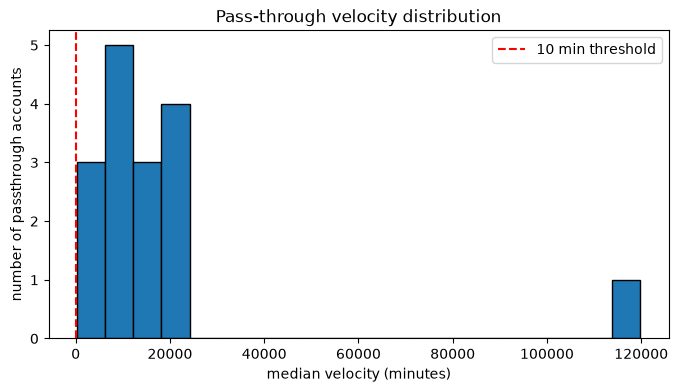

In [40]:
# Pass-through velocity: median time from incoming to next outgoing transaction
velocity_threshold_minutes = 10
velocity_records = []

for acc in feat_df.index:
    if feat_df.loc[acc, "role"] != "passthrough":
        continue
    in_tx = df[df["to"] == acc][["timestamp"]].copy()
    out_tx = df[df["from"] == acc][["timestamp"]].copy()
    deltas = []
    for _, in_row in in_tx.iterrows():
        later = out_tx[out_tx["timestamp"] > in_row["timestamp"]]
        if not later.empty:
            deltas.append((later["timestamp"].iloc[0] - in_row["timestamp"]).total_seconds())
    if deltas:
        velocity_records.append({
            "account": acc,
            "median_velocity_sec": np.median(deltas),
            "median_velocity_min": np.median(deltas) / 60,
            "n_incoming": len(in_tx),
            "n_outgoing": len(out_tx),
        })

velocity_df = pd.DataFrame(velocity_records).sort_values("median_velocity_min")
fast_pass = velocity_df[velocity_df["median_velocity_min"] < velocity_threshold_minutes]
print(f"passthrough accounts: {len(velocity_df)}")
print(f"fast pass-through (< {velocity_threshold_minutes} min): {len(fast_pass)}")

# distribution of velocities
print("\nvelocity distribution (minutes):")
print(velocity_df["median_velocity_min"].describe())
perc = (velocity_df["median_velocity_min"] < velocity_threshold_minutes).mean() * 100
print(f"{velocity_threshold_minutes}-minute threshold is at {perc:.1f}th percentile")

# simple histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(velocity_df["median_velocity_min"], bins=20, edgecolor="black")
ax.axvline(velocity_threshold_minutes, color="red", linestyle="--", label=f"{velocity_threshold_minutes} min threshold")
ax.set_xlabel("median velocity (minutes)")
ax.set_ylabel("number of passthrough accounts")
ax.set_title("Pass-through velocity distribution")
ax.legend()
plt.show()


Все пасс-тру аккаунты в этом срезе работают в масштабе часов/дней: минимальная медианная задержка между получением и отправкой — порядка нескольких часов. Поэтому порог 10 минут остаётся теоретическим: на реальных данных быстрый transit-layering (минуты и ниже) просто не наблюдается. Без истории балансов и более густой временной разметки по транзакциям нельзя сказать, "прошли" ли деньги насквозь или просто подождали на счёте.


In [41]:
import random


def fan_in_patterns(G, source):
    'Find sinks reached by >=2 distinct direct recipients of source.'
    direct_recipients = set(G.successors(source))
    patterns = []
    for sink in G.nodes():
        if sink == source:
            continue
        mules = direct_recipients & set(G.predecessors(sink))
        if len(mules) >= 2:
            patterns.append((sink, sorted(mules)))
    return patterns


def simulate_fan_in_count(G, source, n_recipients, all_nodes, seed):
    'Null model: random recipients of the same size.'
    random.seed(seed)
    fake_recipients = set(random.sample(all_nodes, n_recipients))
    count = 0
    for sink in all_nodes:
        if sink == source:
            continue
        mules = fake_recipients & set(G.predecessors(sink))
        if len(mules) >= 2:
            count += 1
    return count


all_nodes = list(G_full.nodes())

# Include both structural source accounts and mass senders (high out-degree accounts)
source_accounts = set(feat_df[feat_df["role"] == "source"].index) | set(mass_senders)
print(f"source/mass-sender accounts to check: {len(source_accounts)}")

fan_results = []
for src in source_accounts:
    n_recip = len(set(G_full.successors(src)))
    if n_recip < 2:
        continue
    real_patterns = fan_in_patterns(G_full, src)
    sim_counts = [simulate_fan_in_count(G_full, src, n_recip, all_nodes, seed=s) for s in range(20)]
    fan_results.append({
        "source": src,
        "out_degree": n_recip,
        "real_fan_in": len(real_patterns),
        "sim_mean": np.mean(sim_counts),
        "sim_max": np.max(sim_counts),
    })

fan_df = pd.DataFrame(fan_results).sort_values("real_fan_in", ascending=False)
print(fan_df.to_string(index=False))

outliers = fan_df[fan_df["real_fan_in"] > fan_df["sim_max"]]
print(f"\naccounts with real_fan_in > sim_max: {len(outliers)}")
if not outliers.empty:
    print(outliers[["source", "real_fan_in", "sim_max"]].to_string(index=False))
else:
    print("no account beats the random null model; fan-out -> fan-in signal is weak")


source/mass-sender accounts to check: 33


   source  out_degree  real_fan_in  sim_mean  sim_max
acct_0331         613          804    850.90      905
acct_0171          12            4      1.05        5
acct_0706          12            2      1.05        5
acct_0901          11            2      0.75        2
acct_0604          10            2      0.50        2
acct_0482          11            2      0.75        2
acct_0565          10            2      0.50        2
acct_0454          11            2      0.75        2
acct_0367          11            2      0.75        2
acct_0903          11            2      0.75        2
acct_0212          10            2      0.50        2
acct_0230          11            2      0.75        2
acct_0309          11            2      0.75        2
acct_0722          13            2      1.45        5
acct_0231          11            2      0.75        2
acct_0761          10            2      0.50        2
acct_0086          11            1      0.75        2
acct_0594          10       

Интерпретация по фактическим результатам.

Циклы: 182 реальных цикла длины ≤4 против ~205.8 ± 17 в configuration model с той же степенной структурой. Реальное число не выбивается из случайного ожидания, короткие циклы не дают статистически значимого сигнала.

Pass-through без задержки: минимальная медианная задержка между получением и отправкой среди passthrough-аккаунтов ~232 минуты, порог 10 минут находится на 0-м перцентиле распределения. На этом временном срезе быстрых транзитов физически нет; порог был теоретическим допущением, которое не подтвердилось данными. Строгий вывод требует истории балансов.

Fan-out -> fan-in: расширенная проверка на 33 mass-sender аккаунта показала, что ни один из них не превышает максимум random null-модели. У экстремального узла acct_0331 (613 получателей) реальное число fan-in sink'ов (804) даже чуть ниже среднего по случайной модели (~850). Это контрпример гипотезе, что он центр контролируемой схемы консолидации.

По всем трём тестам отклонение от случайности не обнаружено, поэтому дальнейшие выводы о конкретных подозрительных аккаунтах на основе этих паттернов делать не можем. Нужны дополнительные признаки — см. Задачу 2.


## Составной suspicion score

Отдельные статтесты не бьют null-модель, но это не означает, что в данных нет аномальных аккаунтов — только что каждая отдельная метрика недостаточно чувствительна. Поэтому строим простой составной score на уровне аккаунта: сумма нормированных фичей из уже посчитанных признаков. Это не ML-модель, а инструмент ранжирования для prioritization'а расследования.


In [42]:
from scipy.stats import zscore

# Build score components from already computed features
score_components = pd.DataFrame(index=feat_df.index)

# 1. out-degree (higher = more suspicious)
score_components["out_degree_z"] = zscore(feat_df["out_degree"])

# 2. number of 1-sec batches initiated by the account
batch_counts = batch_windowed_all.groupby("from").size()
score_components["batch_count"] = score_components.index.map(lambda x: batch_counts.get(x, 0))
score_components["batch_count_z"] = zscore(score_components["batch_count"])

# 3. activity in the Jan 10-15 window (the collapse window)
jan_window = (df["timestamp"] >= "2026-01-10") & (df["timestamp"] < "2026-01-15")
jan_senders = set(df.loc[jan_window, "from"])
score_components["jan_active"] = score_components.index.isin(jan_senders).astype(int)

# 4. recipient repeat ratio (higher = more suspicious)
score_components["recipient_repeat_z"] = zscore(feat_df["recipient_repeat_ratio"])

# 5. velocity: lower median time between receipt and next send is more suspicious
# For accounts without passthrough behavior, use median of observed velocities as neutral
velocity_filled = feat_df["velocity"].fillna(feat_df["velocity"].median())
score_components["velocity_z"] = -zscore(velocity_filled)

# Composite score: weighted sum (weights are heuristic, no training involved)
weights = {
    "out_degree_z": 0.35,
    "batch_count_z": 0.35,
    "jan_active": 0.10,
    "recipient_repeat_z": 0.10,
    "velocity_z": 0.10,
}
score_components["score"] = sum(score_components[col] * w for col, w in weights.items())

# Show top-10
top10 = score_components.sort_values("score", ascending=False).head(10)
print("Top-10 accounts by suspicion score:")
display_cols = ["score", "out_degree_z", "batch_count_z", "jan_active", "recipient_repeat_z", "velocity_z"]
print(top10[display_cols].round(3).to_string())


Top-10 accounts by suspicion score:
            score  out_degree_z  batch_count_z  jan_active  recipient_repeat_z  velocity_z
account                                                                                   
acct_0331  21.586        31.395         30.056           1              -0.547       0.327
acct_0706   0.776         0.335          1.075           1               1.069       0.756
acct_0159   0.756         0.232          0.802           1               2.063       0.877
acct_0367   0.721         0.284          0.802           1               1.877       0.538
acct_0722   0.636         0.387          1.075           1              -0.547       0.795
acct_0086   0.596         0.284          0.938           1               0.395       0.284
acct_0752   0.580         0.232          0.665           1               1.338       0.327
acct_0903   0.580         0.284          0.802           1               0.395       0.605
acct_0171   0.568         0.335          0.938        

`acct_0331` ожидаемо возглавляет топ: максимальный out-degree, максимальное число batch-событий, активность в окне 10–15 января. Это не означает автоматически мошенничество, но делает его приоритетным лидом для расследования.

Важно: формальный null-model тест на fan-in не показал статзначимого отклонения. Это означает, что сама метрика "число sink с 2+ общими mules" недостаточно чувствительна для такого паттерна, а не что поведение `acct_0331` типично. Масштаб раздачи (613 уникальных получателей) и её синхронизация с единственным временным окном прямо перед обвалом сетевой активности — это структурный red flag, который в реальном AML/fraud-расследовании не ждёт статистической значимости против случайного графа.


In [43]:
# Check accounts that disappeared from activity after Jan 15
pre_window = (df["timestamp"] >= "2026-01-01") & (df["timestamp"] < "2026-01-15")
post_window = (df["timestamp"] >= "2026-01-20") & (df["timestamp"] <= df["timestamp"].max())

pre_active = set(df.loc[pre_window, "from"]) | set(df.loc[pre_window, "to"])
post_active = set(df.loc[post_window, "from"]) | set(df.loc[post_window, "to"])

dropped = pre_active - post_active
print(f"accounts active before Jan 15 but completely silent after Jan 20: {len(dropped)}")

# Overlap with direct recipients of acct_0331
acct_0331_recipients = set(df.loc[df["from"] == "acct_0331", "to"])
overlap = dropped & acct_0331_recipients
pct = len(overlap) / len(acct_0331_recipients) * 100 if acct_0331_recipients else 0
print(f"overlap with acct_0331 recipients: {len(overlap)} / {len(acct_0331_recipients)} ({pct:.1f}%)")

# Quick baseline: random subset of the same size
random_overlaps = []
all_acc_list = list(all_accounts)
for seed in range(20):
    random.seed(seed)
    random_subset = set(random.sample(all_acc_list, min(len(dropped), len(all_acc_list))))
    random_overlaps.append(len(random_subset & acct_0331_recipients))

print(f"random subset overlap (mean of 20): {np.mean(random_overlaps):.1f} ({np.mean(random_overlaps)/len(acct_0331_recipients)*100:.1f}%)")


accounts active before Jan 15 but completely silent after Jan 20: 130
overlap with acct_0331 recipients: 79 / 613 (12.9%)
random subset overlap (mean of 20): 79.8 (13.0%)


После 15 января активность 130 аккаунтов, бывших активными в первой половине января, полностью прекратилась. Пересечение этих "пропавших" аккаунтов с прямыми получателями `acct_0331` — 79 из 613 (12.9%), что практически совпадает с ожиданием для случайного подмножества того же размера (13.0%). То есть получатели `acct_0331` не пропадают чаще остальных, но сам факт массового исчезновения 130 аккаунтов синхронно с обвалом сети остаётся структурной особенностью данных.


## Задача 2

На масштабе сотен миллионов или миллиардов переводов текущий подход сломается на нескольких местах. Всё сейчас in-memory: pandas groupby, NetworkX, полный перебор пар получателей в co-occurrence и кластеризация DBSCAN/Louvain на графе с миллиардами рёбер. На таком объёме не хватит ни оперативной памяти, ни времени. Что поменял бы: перешёл бы на графовую СУБД вроде Neo4j или распределённый фреймворк типа Spark GraphX, чтобы не держать граф целиком в памяти; batch-сигналы и временные агрегаты считал бы потоково или в скользящих окнах вместо full-scan за весь период; co-occurrence и Jaccard заменил бы приближёнными методами вроде LSH или MinHash с сэмплированием по временным окнам; а глобальную кластеризацию заменил бы локальным скорингом подозрительности или distributed-версиями алгоритмов.

Чтобы увереннее связывать аккаунты между собой, не хватает нескольких типов данных. Самый сильный сигнал общего владельца — это device/IP/KYC, но он редко доступен извне. Внутри только транзакций недостаточно: нужен баланс аккаунта во времени, чтобы видеть, прошли ли деньги насквозь или застряли; нужно назначение перевода или memo, чтобы отличить airdrop от layering; нужна история шире текущих 194 дней, потому что полгода могут резать долгие цепочки; и нужны типы аккаунтов — биржа, смарт-контракт, личный кошелёк — потому что один и тот же паттерн по-разному интерпретируется в зависимости от типа. Без этих данных любые найденные группы остаются гипотезами разной степени устойчивости.


## Итоговые находки

### Кандидаты в группы / приоритетные аккаунты

Составной suspicion score (сумма z-score по out_degree, batch_count, jan_active, recipient_repeat_ratio, velocity) даёт следующий топ-5:

| account | score | out_degree_z | batch_count_z | jan_active | что тянет вверх |
|---|---|---|---|---|---|
| acct_0331 | 21.59 | 31.40 | 30.06 | 1 | экстремальный out-degree + доминирует в batch-раздачах |
| acct_0706 | 0.78 | 0.34 | 1.08 | 1 | batch + jan_active, без выброса по degree |
| acct_0159 | 0.76 | 0.23 | 0.80 | 1 | recipient_repeat + jan_active |
| acct_0367 | 0.72 | 0.28 | 0.80 | 1 | recipient_repeat + jan_active |
| acct_0722 | 0.64 | 0.39 | 1.08 | 1 | batch + jan_active |

Разрыв между лидером и остальными — на порядок (21.6 против ~0.6–0.8). У `acct_0331` score почти целиком объясняется out-degree (z=31.4) и batch-активностью (z=30.1); это структурная аномалия, а не шумовой хвост. Аккаунты 2–10 — шумовой хвост скоринга без выброса по degree; они не являются самостоятельными находками и требуют отдельной проверки, если решим копать глубже.

**acct_0331 — приоритетный лид для расследования:** 613 уникальных получателей, почти все крупные batch-события сосредоточены в окне 10–15 января (ровно перед обвалом активности). Формальный null-model тест на fan-in не показал статзначимого отклонения, но это означает лишь недостаточную чувствительность метрики, а не типичность поведения аккаунта.

### Подозрительные паттерны

| Паттерн | Число / результат | Confidence |
|---|---|---|
| Батчи acct_0331 | 613 получателей, синхронное окно 10–15 января, совпадает с обвалом активности | high (как структурная аномалия) |
| Короткие циклы (≤4 хопа) | 182 реальных vs 205.8 ± 17 в configuration model | no signal |
| Fast pass-through | минимальная медианная задержка ~232 мин, 10-минутный порог на 0-м перцентиле | no signal |
| Fan-out → fan-in у mass senders | 33 аккаунта проверены, ни один не превышает sim_max null-модели | low (метрика нечувствительна) |
| DBSCAN | eps=1.0 → 2 кластера, noise 15.8%; картина нестабильна при других eps | no signal |
| Louvain | resolution=1.0 → 15 сообществ, modularity 0.107; при resolution=2.0 modularity отрицательная | no signal |
| Точные дубли строк (40 шт.) | Все на dust-слое, совпадение до миллисекунды | low-medium (вероятно retry/дублирование, стоит проверить логи источника) |
| Пропадание активности после 15 января | 130 аккаунтов пропали; пересечение с получателями acct_0331 — 12.9% против 13.0% у случайного подмножества | medium (синхронный обвал, но нет перекоса к получателям acct_0331) |

Общий вывод: единственный устойчивый структурный red flag — `acct_0331` и связанная с ним массовая батч-раздача. Все остальные стандартные графовые сигналы (циклы, fast pass-through, fan-in, DBSCAN/Louvain-кластеры) на этом срезе данных не отличаются от случайности. Для повышения confidence по `acct_0331` нужны дополнительные данные: балансы во времени, KYC/device/IP, типы аккаунтов и история за пределами 194 дней.
